In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/social_media_engagement_dataset.csv")
df.head()

,platform,post_type,post_length,views,likes,comments,shares,engagement_rate
0,Facebook,Text,62,91660,2968,276,346,0.039166
1,Instagram,Video,104,113115,4164,632,406,0.045989
2,Facebook,Video,46,36043,3125,188,100,0.094692
3,Facebook,Image,39,124886,5970,948,578,0.060023
4,Instagram,Video,42,82831,8212,1104,334,0.116502


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   post_type        10000 non-null  object 
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB


In [10]:
df.isnull().sum()


,0
platform,0
post_type,0
post_length,0
views,0
likes,0
comments,0
shares,0
engagement_rate,0


In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.describe()

,post_length,views,likes,comments,shares,engagement_rate
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,62.359800,127151.950600,7033.26920,879.232800,602.262700,0.066696
std,33.264888,75169.927932,5673.59828,812.409438,597.573391,0.031598
min,5.000000,2059.000000,35.00000,3.000000,2.000000,0.011227
25%,34.000000,65211.000000,2513.75000,275.000000,170.000000,0.039637
50%,62.000000,122402.500000,5580.50000,635.000000,406.000000,0.066719
75%,91.000000,184217.000000,10276.50000,1228.000000,837.000000,0.093694
max,119.000000,299997.000000,29486.00000,5435.000000,3861.000000,0.132124


In [14]:
total_likes = df['likes'].sum()
print(total_likes)

70332692


In [15]:
avg_engagement = df['engagement_rate'].mean()
print(avg_engagement)

0.06669605191752286


In [16]:
df.groupby('platform')['likes'].sum()

,likes
platform,
Facebook,23419408
Instagram,28375719
Twitter,18537565


In [17]:
df.groupby('post_type')['engagement_rate'].mean()

,engagement_rate
post_type,
Image,0.067147
Text,0.066026
Video,0.066903


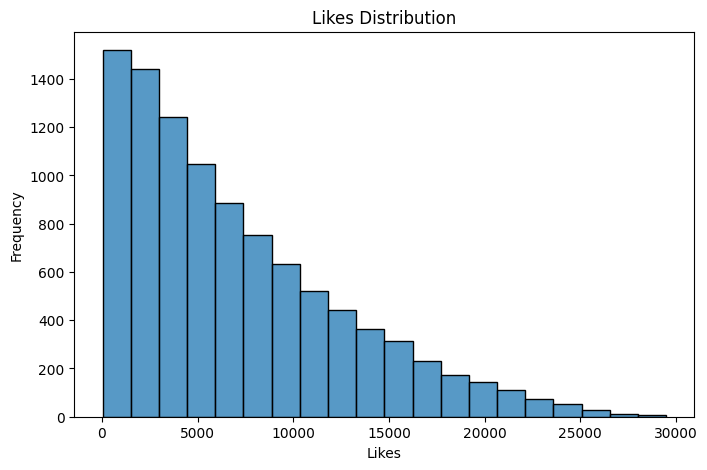

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['likes'], bins=20)

plt.title("Likes Distribution")
plt.xlabel("Likes")
plt.ylabel("Frequency")

plt.show()

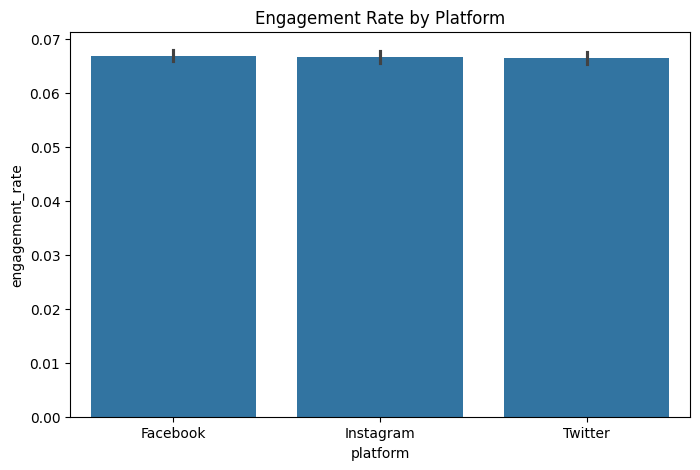

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='platform',
    y='engagement_rate',
    data=df
)

plt.title("Engagement Rate by Platform")

plt.show()

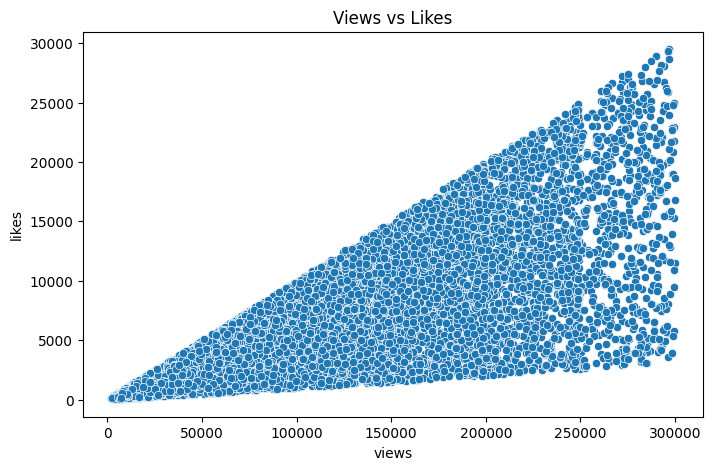

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='views',
    y='likes',
    data=df
)

plt.title("Views vs Likes")

plt.show()

In [21]:
df['post_type'].value_counts()

,count
post_type,
Image,3370
Video,3333
Text,3297


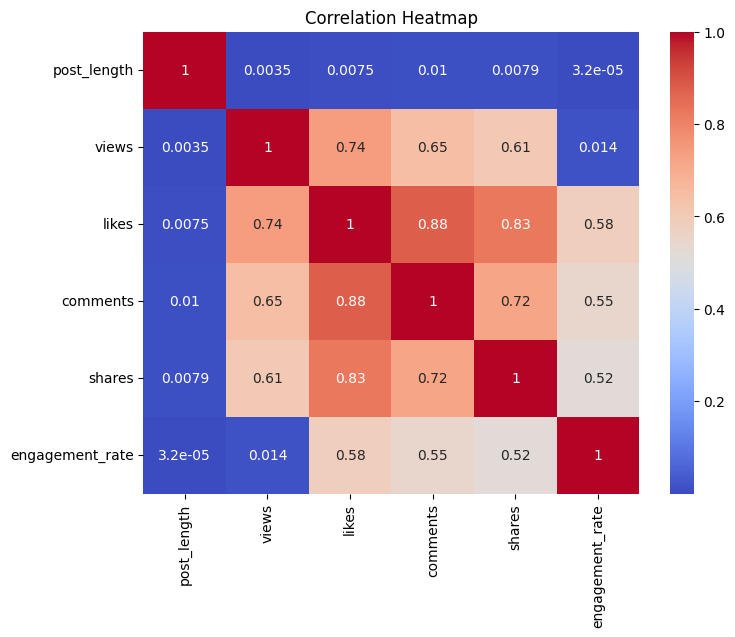

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
df.to_csv("cleaned_social_media_data.csv", index=False)